# redMaPPer $\times$ Compton-y in simulation and ACT $\times$ DES data

This notebook executes the same strict catalog cuts used by `measurements/ACTxDES/Cluster_SZ_measurements.ipynb`: $\lambda>20$ and $0.5<z<0.8$, using the catalog `z` column. It measures the compensated TreeCorr statistic

$$\xi_{cy}(\theta)=\langle y\rangle_{\rm clusters}-\langle y\rangle_{\rm randoms}$$

in 20 logarithmic bins from 2.5 to 250 arcmin. Random samples are deterministic and limited to the smallest converged choice among 5x, 10x, and 20x the cluster count.


In [1]:
%matplotlib inline
import json
import platform
import sys
import time
from pathlib import Path

import h5py
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import treecorr

HERE = Path.cwd()
if HERE.name != 'DES_cluster':
    HERE = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster')
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import redmapper_y_cross as cross

CONFIG = HERE / 'params_redmapper_y_cross.yaml'
plt.rcParams.update({'figure.dpi': 105, 'savefig.dpi': 170})
print({
    'python': platform.python_version(),
    'numpy': np.__version__,
    'matplotlib': matplotlib.__version__,
    'treecorr': treecorr.__version__,
    'config': str(CONFIG),
})


{'python': '3.10.16', 'numpy': '1.26.4', 'matplotlib': '3.9.3', 'treecorr': '4.3.3', 'config': '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster/params_redmapper_y_cross.yaml'}


## Estimator improvements and fixed conventions

- The simulation uses the explicit inclusive first-octant footprint and the supplied radial random catalog.
- The data map uses the ACT $\times$ DES mask threshold from the source notebook. The science curve uses 1.0-arcmin pixels and is checked against the native 0.5-arcmin map. CAR pixels are weighted by their solid angle; equal CAR-pixel weights would over-weight high-$|\mathrm{Dec}|$ rows.
- Jackknife centers are generated deterministically from the retained random footprint, rather than relying on an unproven legacy center file.
- The simulation receives one 1.6-arcmin Gaussian smoothing to follow the established ACT convention. The ACT FITS header does not record `BUNIT`, beam, or transfer metadata, so absolute amplitude/beam matching remains conditional.
- Cluster and random FITS weight columns remain unused to match the source notebook's unweighted catalog convention.


{
  "claim_boundary": "diagnostic only; ACT BUNIT/beam metadata absent; no fitted amplitude or goodness claim",
  "comparison_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison.png",
  "data_central_mean": 4.523923524292944e-07,
  "data_clusters": 7979,
  "data_null_pte": 0.19889957740422273,
  "data_random_ratio": 10,
  "data_resolution": {
    "control_downsample_factor": 1,
    "max_shift_sigma": 0.3668282720568598,
    "median_shift_sigma": 0.028069975208250438,
    "pass": true,
    "science_downsample_factor": 2
  },
  "diagnostics_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_selection_random_diagnostics.png",
  "elapsed_seconds": 361.33739591302583,
  "input_hashes_unchanged": true,
  "result_hdf5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison.h5",
  "simulation_central_mean": 7.219878938483426e-07,
 

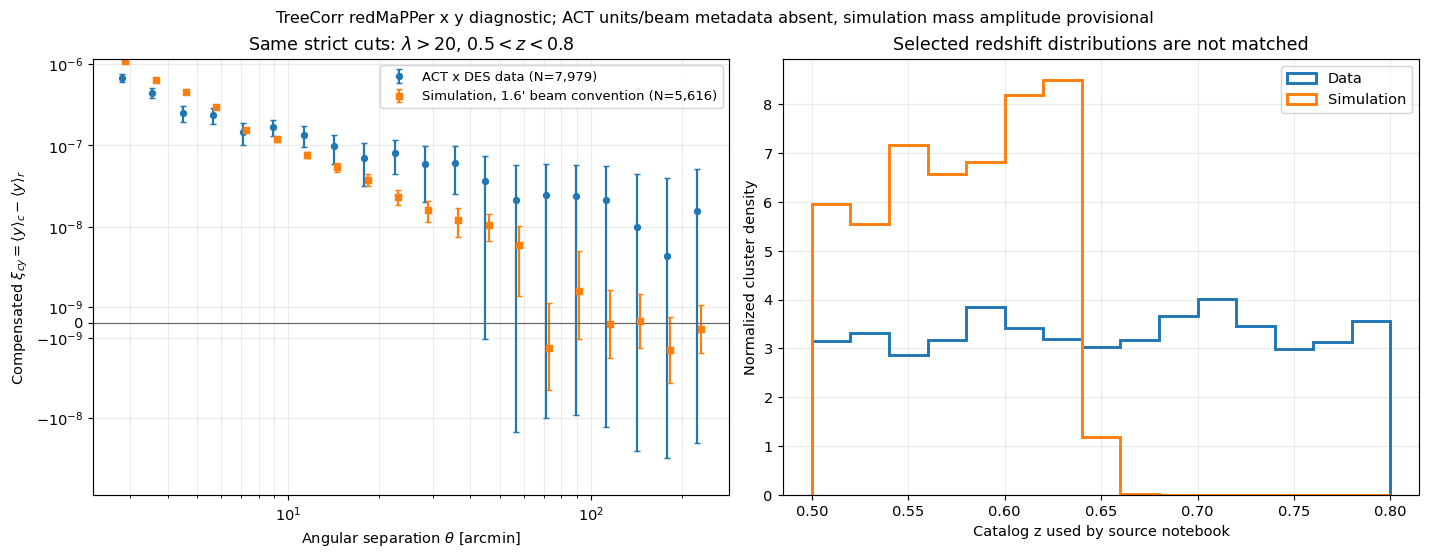

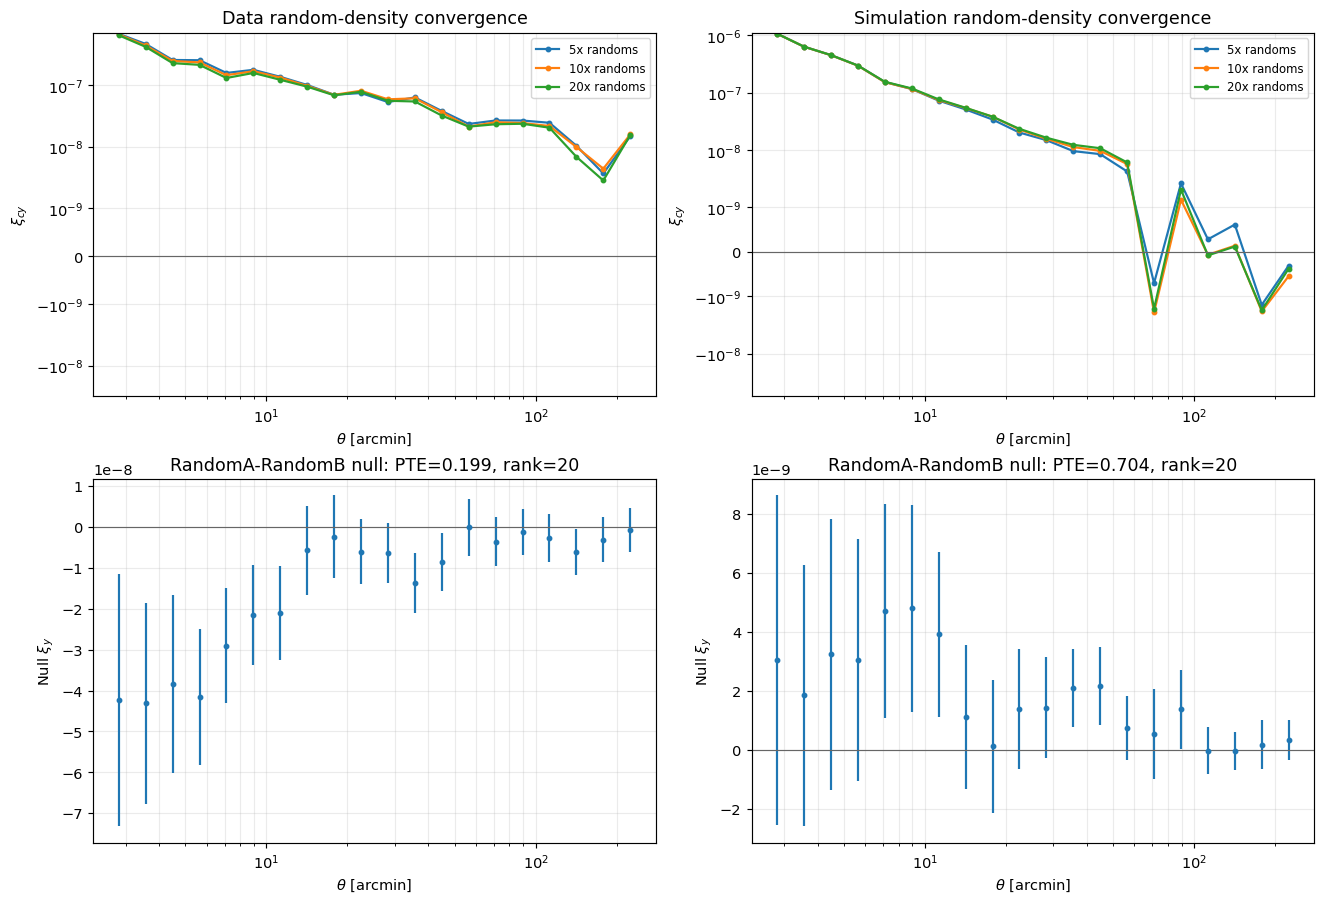

In [2]:
started = time.perf_counter()
analysis = cross.run_analysis(CONFIG)
elapsed_seconds = time.perf_counter() - started
print(json.dumps({**analysis['summary'], 'elapsed_seconds': elapsed_seconds}, indent=2, sort_keys=True))


## Final simulation/data comparison

The horizontal axis is logarithmic and the vertical axis is symmetric-log so negative noisy bins remain visible. Error bars are separate 100-patch jackknife estimates. The right panel shows that identical top-hat cuts do **not** make the simulation and data redshift distributions identical; no amplitude fit or goodness-of-fit comparison is made.


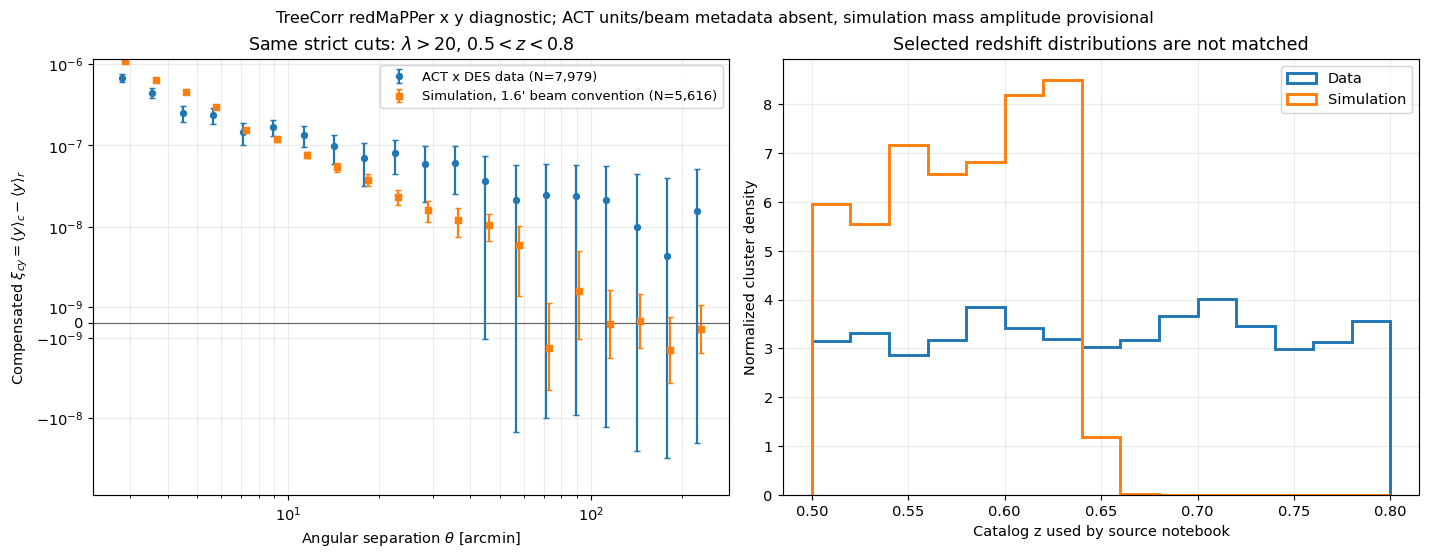

Saved /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison.png


In [3]:
display(analysis['comparison_figure'])
print(f"Saved {analysis['comparison_path']}")


## Random-density and random-position null controls

The upper panels show the compensated profile as the random density increases from 5x to 10x and 20x the cluster count. The lower panels compare two disjoint deterministic 10x random subsets. The displayed PTE is a goodness-of-null diagnostic from the retained jackknife-covariance rank, not a detection significance.


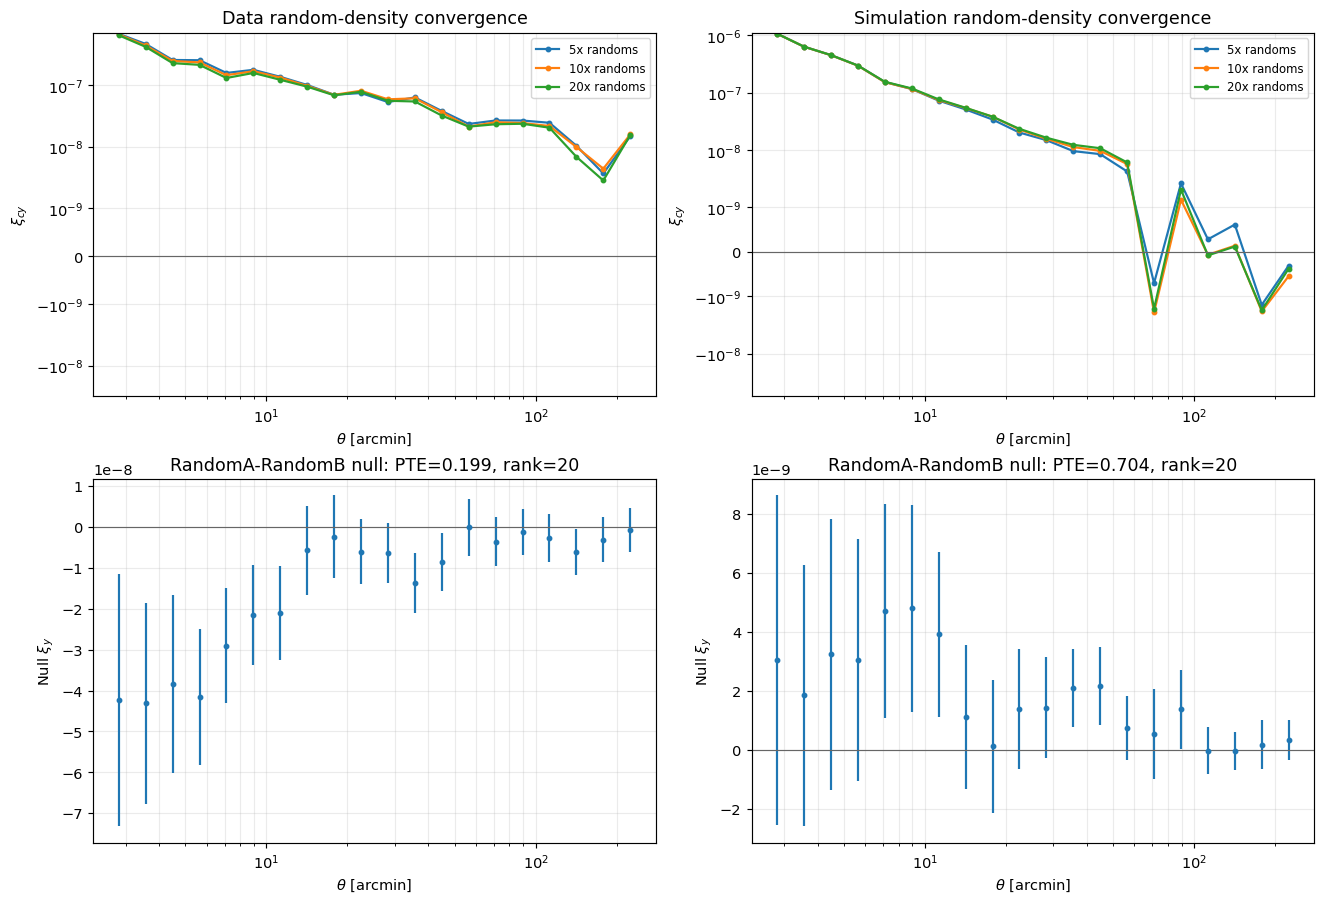

Saved /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_selection_random_diagnostics.png
{
  "data": {
    "chosen_random_ratio": 10,
    "cluster_patch_count_max": 135,
    "cluster_patch_count_min": 36,
    "null_test": {
      "chi2": 25.066479944032636,
      "eigenvalue_threshold": 1.528569974152532e-25,
      "pte": 0.19889957740422273,
      "rank": 20
    },
    "random_convergence": {
      "5": {
        "max_shift_sigma": 0.8520435300531977,
        "median_shift_sigma": 0.1413633269544394,
        "pass": false
      },
      "10": {
        "max_shift_sigma": 0.43804522046275735,
        "median_shift_sigma": 0.08738143262465095,
        "pass": true
      },
      "20": {
        "max_shift_sigma": 0.0,
        "median_shift_sigma": 0.0,
        "pass": true
      }
    }
  },
  "simulation": {
    "chosen_random_ratio": 20,
    "cluster_patch_count_max": 82,
    "cluster_patch_count_min": 35,
    "null_test": {
      "chi2": 16.2040

In [4]:
display(analysis['diagnostics_figure'])
print(f"Saved {analysis['diagnostics_path']}")
print(json.dumps({
    label: {
        'chosen_random_ratio': analysis[label]['chosen_random_ratio'],
        'random_convergence': analysis[label]['random_convergence'],
        'null_test': analysis[label]['null_test'],
        'cluster_patch_count_min': analysis[label]['cluster_patch_count_min'],
        'cluster_patch_count_max': analysis[label]['cluster_patch_count_max'],
    } for label in ('simulation', 'data')
}, indent=2, sort_keys=True))


## Fail-closed checks and saved product

The compact HDF5 stores the unbinned profiles, full jackknife covariances, nulls, random-density controls, cluster distributions, input/config/helper hashes, mask/pixel weights, TreeCorr version, and conditional beam/unit status.


In [5]:
summary = analysis['summary']
with h5py.File(summary['result_hdf5'], 'r') as handle:
    saved = {
        'schema': handle.attrs['schema'],
        'selection': handle.attrs['selection'],
        'estimator': handle.attrs['estimator'],
        'treecorr_version': handle.attrs['treecorr_version'],
        'helper_sha256': handle.attrs['helper_sha256'],
        'noise_policy': json.loads(handle.attrs['noise_policy_json']),
        'cluster_weight_policy': handle.attrs['cluster_weight_policy'],
        'data_transfer_status': handle.attrs['data_transfer_status'],
        'simulation_mass_amplitude_status': handle.attrs['simulation_mass_amplitude_status'],
        'input_sha256': json.loads(handle.attrs['input_sha256_json']),
    }
checks = {
    'result_schema': saved['schema'] == cross.RESULT_SCHEMA,
    'input_hashes_unchanged': summary['input_hashes_unchanged'],
    'simulation_cluster_identity': analysis['simulation_clusters']['pre_mask_row_index_sha256'] == analysis['config']['simulation']['expected_pre_mask_row_index_sha256'],
    'data_cluster_identity': analysis['data_clusters']['pre_mask_row_index_sha256'] == analysis['config']['data']['expected_pre_mask_row_index_sha256'],
    'simulation_central_positive': summary['simulation_central_mean'] > 0.0,
    'data_central_positive': summary['data_central_mean'] > 0.0,
    'simulation_random_null': summary['simulation_null_pte'] > analysis['config']['randoms']['null_pte_min'],
    'data_random_null': summary['data_null_pte'] > analysis['config']['randoms']['null_pte_min'],
    'data_pixel_resolution': summary['data_resolution']['pass'],
    'bounded_simulation_randoms': summary['simulation_random_ratio'] in (5, 10, 20),
    'bounded_data_randoms': summary['data_random_ratio'] in (5, 10, 20),
}
assert all(checks.values()), checks
print(json.dumps({'checks': checks, 'saved': saved, 'summary': summary}, indent=2, sort_keys=True))


{
  "checks": {
    "bounded_data_randoms": true,
    "bounded_simulation_randoms": true,
    "data_central_positive": true,
    "data_cluster_identity": true,
    "data_pixel_resolution": true,
    "data_random_null": true,
    "input_hashes_unchanged": true,
    "result_schema": true,
    "simulation_central_positive": true,
    "simulation_cluster_identity": true,
    "simulation_random_null": true
  },
  "saved": {
    "cluster_weight_policy": "unit_weights_to_match_source_notebook_catalog_w_intentionally_unused",
    "data_transfer_status": "filter_transfer_not_recorded_in_FITS_header",
    "estimator": "TreeCorr NK: <y>_cluster - <y>_random",
    "helper_sha256": "5caecfce2560d3ae7d8d8b752b434c16b1cd6649084e128d68349c5b232df17c",
    "input_sha256": {
      "data_cluster": "8ba4319310cb9a1174b3fa50410bcfb3329e37dd5433d0b8748ec5f43b2fff2a",
      "data_mask": "1e4346196a40828ba05d63612026c5184a046c3a42ec4cfb214e44e7fa2be863",
      "data_random": "83e58d83095c5aeae98ed2c6d23f3e8c5

## Interpretation boundary

This is an estimator-matched diagnostic of one simulation realization and the chosen ACT $\times$ DES map. The simulation redMaPPer sample ends near $z\simeq0.66$ despite the common $z<0.8$ cut. The ACT file lacks local unit/beam/transfer metadata, the simulation random `R` unit is geometry-inferred, and `M_interp` is provisionally treated as $M_{200c}$. Therefore the overlay is not a calibrated amplitude test, likelihood, or detection claim; those require selection matching and confirmed map provenance.
